# 08 - Build the GPT

Now we assemble everything (attention, multi-head attention, the feed-forward network, LayerNorm, the residuals, and the embeddings) into a complete **GPT**. To keep it reusable, the model lives in a file called `gpt.py`, so that notebooks 09 and 10 can simply import it. This notebook is a guided tour of that file: we read each class in turn and explain what it does and why.

Here is the whole journey a token takes, from top to bottom:

```
token ids ->  token embedding  +  position embedding
          ->  N x Transformer block   (attention + feed-forward, with residuals)
          ->  final LayerNorm
          ->  linear head  ->  logits over the vocabulary (next-token scores)
```

In words: turn each token id into a vector and add in *where* it sits; let the stack of blocks mix and refine those vectors; give them a final clean-up; then read out a score for every possible next token. That last list of scores is exactly what softmax and sampling turn into the next character.

In [1]:
# Colab setup -- fetch the files this notebook needs.
# (Does nothing when run locally in the course folder.)
import os, urllib.request
BASE = ("https://raw.githubusercontent.com/waze"
        "emlabs/llm-book-code/main/")
for f in ['gpt.py', 'data/input.txt']:
    if not os.path.exists(f):
        d = os.path.dirname(f)
        if d: os.makedirs(d, exist_ok=True)
        urllib.request.urlretrieve(BASE + f, f)
        print("downloaded", f)


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>import os, urllib.request</code>: two standard-library toolboxes: checking files on disk, and downloading from the web.</li>
<li><code>BASE = (...)</code>: the web address of this course's folder on GitHub, split over two lines (Python glues adjacent strings together).</li>
<li><code>for f in [...]</code>: loop over the file names this notebook needs.</li>
<li><code>if not os.path.exists(f)</code>: only download what is missing -- running locally, everything already exists, so nothing happens.</li>
<li><code>os.makedirs(d, exist_ok=True)</code>: create the folder for the file if it has one (<code>exist_ok</code> means don't complain if it's already there).</li>
<li><code>urllib.request.urlretrieve(...)</code>: download the file and save it under the same name here.</li>
</ul>
</details>

In [2]:
import torch, inspect
from gpt import GPTConfig, Head, MultiHeadAttention, FeedForward, Block, GPT
torch.manual_seed(1337)                       # reproducible init + untrained sample
device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print("model lives in gpt.py | device:", device)

model lives in gpt.py | device: mps


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>import torch, inspect</code>: PyTorch, plus <code>inspect</code>, a standard tool that can fetch a class's <i>source code</i> as text.</li>
<li><code>from gpt import GPTConfig, Head, ...</code>: import the model's classes from the local file <code>gpt.py</code>, so notebooks 08-10 all share the exact same code.</li>
<li><code>torch.manual_seed(1337)</code>: fix the seed so the untrained sample lower down is reproducible (the same seed the other notebooks use).</li>
<li>The device line picks Apple GPU &rarr; NVIDIA &rarr; CPU, as before.</li>
</ul>
</details>

## Config

Every size of the model, gathered in one place. Think of these as the dials you turn up for a larger and more capable (but slower and more demanding) model: more **layers** (`n_layer`) makes it deeper; a wider embedding (`n_embd`) gives each token more room to represent meaning; more **heads** (`n_head`) lets it track more relationships at once; and a longer **block_size** lets it look further back. Our values are deliberately tiny, so the whole thing trains in about a minute.

In [3]:
print(inspect.getsource(GPTConfig))

@dataclass
class GPTConfig:
    vocab_size: int = 65      # number of distinct tokens
    block_size: int = 128     # maximum context length (tokens the model can look back over)
    n_layer: int = 4          # number of Transformer blocks
    n_head: int = 4           # attention heads per block
    n_embd: int = 128         # embedding / residual-stream width
    dropout: float = 0.0      # dropout probability (set >0 to regularize larger runs)



<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>print(inspect.getsource(GPTConfig))</code>: fetch and print the class's real source from gpt.py. What you see below <i>is</i> the actual code.</li>
<li><code>@dataclass</code>: a decorator (the @ line above the class) that auto-writes the boring constructor: you just declare fields with types and defaults, and <code>GPTConfig(vocab_size=65)</code> works.</li>
<li><code>vocab_size: int = 65</code>: a field: its name, its type, its default. Pure settings, no behavior. The other fields (<code>block_size</code>, <code>n_layer</code>, <code>n_head</code>, <code>n_embd</code>) are the size dials you turn up for a bigger model.</li>
</ul>
</details>

## One attention head

This is identical to notebook 05, now written as a trainable `nn.Module`. `key`, `query`, and `value` are the learned projections; the `tril` buffer enforces causality (no looking at the future); and the `1/sqrt(d)` scaling keeps softmax soft (notebook 05, step 4). Nothing here is new; it is the same head, wired up so that autograd can train it.

In [4]:
print(inspect.getsource(Head))

class Head(nn.Module):
    """One head of causal self-attention (notebook 05, now with learned, trainable weights)."""

    def __init__(self, cfg: GPTConfig, head_size: int):
        super().__init__()
        self.key = nn.Linear(cfg.n_embd, head_size, bias=False)
        self.query = nn.Linear(cfg.n_embd, head_size, bias=False)
        self.value = nn.Linear(cfg.n_embd, head_size, bias=False)
        # a constant lower-triangular mask; registered as a buffer so it moves with .to(device)
        self.register_buffer("tril", torch.tril(torch.ones(cfg.block_size, cfg.block_size)))
        self.dropout = nn.Dropout(cfg.dropout)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)            # (B, T, head_size)
        q = self.query(x)          # (B, T, head_size)
        # scaled dot-product affinities, then mask out the future
        wei = q @ k.transpose(-2, -1) * k.shape[-1] ** -0.5   # (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float("-

<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li>This prints notebook 07's <code>Head</code>, with two production touches:</li>
<li><code>self.key/query/value = nn.Linear(...)</code>: the three learned projections, as layers.</li>
<li><code>self.register_buffer("tril", ...)</code>: the causal mask, carried with the model but not trained.</li>
<li><code>self.dropout = nn.Dropout(cfg.dropout)</code>: during training, randomly zero a fraction of the attention weights (regularization, explained in notebook 09). With <code>dropout=0.0</code> it does nothing.</li>
<li><code>wei = q @ k.transpose(-2,-1) * k.shape[-1]**-0.5</code> ... -- scale, mask, softmax, blend: line-for-line what you built in notebooks 05 and 07.</li>
<li>The <code>"""..."""</code> right under the class line is a <b>docstring</b> -- documentation tools can read it; Python ignores it at runtime.</li>
</ul>
</details>

## Multi-head attention

Run several heads in parallel and join their outputs together, so the model can attend to different kinds of relationship at once, then use a projection (`proj`) to mix them back to the embedding width (notebook 06). The split `head_size = n_embd // n_head` is what keeps the heads affordable: four heads each do a quarter-width job, so the total cost matches that of a single full-width head.

In [5]:
print(inspect.getsource(MultiHeadAttention))

class MultiHeadAttention(nn.Module):
    """Several attention heads in parallel, concatenated and projected (notebook 06)."""

    def __init__(self, cfg: GPTConfig):
        super().__init__()
        head_size = cfg.n_embd // cfg.n_head
        self.heads = nn.ModuleList([Head(cfg, head_size) for _ in range(cfg.n_head)])
        self.proj = nn.Linear(cfg.n_embd, cfg.n_embd)
        self.dropout = nn.Dropout(cfg.dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)   # (B, T, n_embd)
        return self.dropout(self.proj(out))



<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>head_size = cfg.n_embd // cfg.n_head</code>: split the width across heads (128 / 4 = 32 each).</li>
<li><code>self.heads = nn.ModuleList([Head(cfg, head_size) for _ in range(cfg.n_head)])</code>: a list of heads that PyTorch <i>knows about</i> (a plain Python list would hide their parameters from the optimizer).</li>
<li><code>torch.cat([h(x) for h in self.heads], dim=-1)</code>: run every head, then glue their outputs side by side along the last axis: 4 heads &times; 32 = 128. This is the "concatenate" from notebook 06.</li>
<li><code>self.proj</code> then <code>self.dropout</code>: a final projection that mixes the heads, then dropout.</li>
</ul>
</details>

## Feed-forward

After the tokens have traded information through attention, each one is processed on its own by a small MLP: expand to four times the width, apply GELU, then project back (notebook 06). This is the "now think about what you just heard" step, and most of the model's numbers live here.

In [6]:
print(inspect.getsource(FeedForward))

class FeedForward(nn.Module):
    """Per-token MLP: expand 4x, nonlinearity, project back. Where most parameters live."""

    def __init__(self, cfg: GPTConfig):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cfg.n_embd, 4 * cfg.n_embd),
            nn.GELU(),
            nn.Linear(4 * cfg.n_embd, cfg.n_embd),
            nn.Dropout(cfg.dropout),
        )

    def forward(self, x):
        return self.net(x)



<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>self.net = nn.Sequential(...)</code>: a pipeline: each layer feeds the next, in order. Calling <code>self.net(x)</code> runs the whole chain.</li>
<li><code>nn.Linear(n_embd, 4 * n_embd)</code> &rarr; <code>nn.GELU()</code> &rarr; <code>nn.Linear(4 * n_embd, n_embd)</code>: widen 4&times;, bend, narrow back: notebook 06's feed-forward, with PyTorch's exact GELU.</li>
<li><code>nn.Dropout(cfg.dropout)</code>: the same regularization knob at the end.</li>
<li><code>def forward(self, x): return self.net(x)</code>: just run the pipeline.</li>
</ul>
</details>

## The block

One block is attention (communicate) followed by the feed-forward network (think), each wrapped in pre-norm and a residual connection. Stacking these blocks is the entire depth of the network. The residual, written `x = x + sublayer(norm(x))` (keep the input, add an edit on top), is what lets the gradients flow cleanly through a deep stack (notebook 06).

In [7]:
print(inspect.getsource(Block))

class Block(nn.Module):
    """Transformer block: communicate (attention), then compute (MLP). Pre-norm + residuals."""

    def __init__(self, cfg: GPTConfig):
        super().__init__()
        self.ln1 = nn.LayerNorm(cfg.n_embd)
        self.sa = MultiHeadAttention(cfg)
        self.ln2 = nn.LayerNorm(cfg.n_embd)
        self.ffwd = FeedForward(cfg)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))     # residual connection around attention
        x = x + self.ffwd(self.ln2(x))   # residual connection around the feed-forward
        return x



<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>self.ln1 = nn.LayerNorm(cfg.n_embd)</code> (and ln2) -- the LayerNorm you wrote by hand in notebook 06, now built in, with learned dials.</li>
<li><code>self.sa = MultiHeadAttention(cfg)</code> / <code>self.ffwd = FeedForward(cfg)</code>: the two sub-layers.</li>
<li><code>x = x + self.sa(self.ln1(x))</code>: normalize &rarr; attend &rarr; add back (residual).</li>
<li><code>x = x + self.ffwd(self.ln2(x))</code>: normalize &rarr; think &rarr; add back. Two lines, the whole block.</li>
</ul>
</details>

## The full GPT

This is the whole model, and every line should look familiar by now:

- `token_embedding`: a lookup table that turns each token id into a learnable vector (its "meaning"). Nothing assigns these meanings by hand; the vectors start out random and are nudged by training until tokens used in similar ways end up with similar vectors. Meaning emerges from usage.
- `position_embedding`: a second table that adds in *where* the token sits (notebook 06's position information, learned here rather than fixed as sinusoids).
- `blocks`: the stack of Transformer blocks that do the real work.
- `ln_f` and then `lm_head`: a final LayerNorm clean-up, followed by a linear layer that turns each position's vector into **logits over the vocabulary**, that is, a score for every possible next token.

If you pass in `targets`, the model also returns the cross-entropy loss (notebook 01). And `generate` is the autoregressive sampling loop from notebook 03, with two new dials we will explore in notebook 10 (`temperature` and `top_k`): predict, take the last position's logits, optionally filter them, apply softmax, draw one token, append it, and repeat, always cropping the context to the last `block_size` tokens so the model never looks back further than it was trained to.

In [8]:
print(inspect.getsource(GPT))

class GPT(nn.Module):
    """The full model: embeddings -> stacked blocks -> final norm -> next-token logits."""

    def __init__(self, cfg: GPTConfig):
        super().__init__()
        self.cfg = cfg
        self.token_embedding = nn.Embedding(cfg.vocab_size, cfg.n_embd)
        self.position_embedding = nn.Embedding(cfg.block_size, cfg.n_embd)
        self.blocks = nn.Sequential(*[Block(cfg) for _ in range(cfg.n_layer)])
        self.ln_f = nn.LayerNorm(cfg.n_embd)
        self.lm_head = nn.Linear(cfg.n_embd, cfg.vocab_size)
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok = self.t

<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>self.token_embedding = nn.Embedding(cfg.vocab_size, cfg.n_embd)</code>: the meaning table: 65 rows (one per character), 128 numbers each.</li>
<li><code>self.position_embedding = nn.Embedding(cfg.block_size, cfg.n_embd)</code>: the same idea for positions 0..127.</li>
<li><code>self.blocks = nn.Sequential(*[Block(cfg) for _ in range(cfg.n_layer)])</code>: build n_layer Blocks; the <code>*</code> unpacks the list into separate arguments.</li>
<li><code>self.ln_f</code> / <code>self.lm_head</code>: a final LayerNorm, then a Linear that turns each token's 128 numbers into 65 next-token scores.</li>
<li><code>self.apply(self._init_weights)</code>: run a small setup on every sub-module: start weights small-random (std 0.02), biases at zero. Good starting points matter.</li>
<li><code>x = tok + pos</code>: meaning plus position, added together (broadcasting fills the batch axis).</li>
<li><code>@torch.no_grad()</code> above <code>generate</code>: a decorator meaning "don't record gradients": generation is pure inference.</li>
<li>Inside <code>generate</code>: crop to the last <code>block_size</code> tokens, keep only the <b>last</b> position's logits, divide by temperature, optionally keep just the top-k (<code>torch.topk</code> finds them; everything below gets -inf), softmax, then <code>torch.multinomial(probs, 1)</code> rolls the weighted die and <code>torch.cat</code> appends it.</li>
<li><code>num_params()</code>: add up <code>p.numel()</code> (element count) over every weight grid: the parameter total.</li>
</ul>
</details>

## Instantiate it

Build a real, if small, GPT sized for our character data, and count its numbers. It comes out at around **825,000**, which sounds like a lot until you learn that GPT-3 has 175 billion, roughly **200,000 times more**. The striking part is that the design you are looking at is, line for line, what the giant models use. They are the same thing, only far wider, far deeper, and trained on far more text.

Four numbers have to be chosen, and each has a reason behind it:

- **`block_size=128`** - how far back the model can see, in characters. A typical line of the play runs about 39 characters, so 128 is roughly three of them: enough to hold a speaker's name and the line beneath it. Double it and every attention step costs four times as much; halve it and the model loses sight of who is speaking.
- **`n_embd=128`** - how many numbers carry each token through the model.
- **`n_head=4`** - four kinds of relationship tracked at once, each head getting 128 / 4 = 32 numbers.
- **`n_layer=4`** - four rounds of "gather context, then think about it."

The constraint governing all four is patience, not accuracy: these sizes train in about a minute on a free Colab GPU.

One of the four is not freely choosable. `n_embd` must divide evenly by `n_head`, because the heads split the width between them:

In [9]:
for h in [4, 5]:
    print(f"n_head={h}: 128 // {h} = {128 // h}"
          f" per head, {h} heads cover"
          f" {h * (128 // h)} of 128")


n_head=4: 128 // 4 = 32 per head, 4 heads cover 128 of 128
n_head=5: 128 // 5 = 25 per head, 5 heads cover 125 of 128


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>for h in [4, 5]:</code>: try a head count that divides 128 evenly, and one that does not.</li>
<li><code>128 // {h}</code>: <code>//</code> divides and throws away the remainder, so 128 // 5 is 25, not 25.6.</li>
<li><code>{h * (128 // h)} of 128</code>: how much of the width the heads actually cover between them. With 5 heads it is 125: three columns go unaccounted for.</li>
</ul>
</details>

Nothing complains when a model with `n_head=5` is *built*. The damage only shows once data flows and the `proj` layer, still expecting all 128, is handed 125:

```
RuntimeError: mat1 and mat2 shapes cannot be
multiplied (8x125 and 128x128)
```

That is an error raised far from the line that caused it, which is why the rule is worth knowing before you need it: choose `n_embd` and `n_head` so the division comes out exact.

In [10]:
from pathlib import Path
text = Path("data/input.txt").read_text()
vocab_size = len(sorted(set(text)))

cfg = GPTConfig(vocab_size=vocab_size, block_size=128, n_layer=4, n_head=4, n_embd=128)
model = GPT(cfg).to(device)
print(f"vocab={cfg.vocab_size}  block={cfg.block_size}  layers={cfg.n_layer}  heads={cfg.n_head}  width={cfg.n_embd}")
print(f"total parameters: {model.num_params():,}")

vocab=65  block=128  layers=4  heads=4  width=128
total parameters: 824,897


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>cfg = GPTConfig(vocab_size=vocab_size, block_size=128, n_layer=4, n_head=4, n_embd=128)</code>: fill in the size dials.</li>
<li><code>model = GPT(cfg).to(device)</code>: build the model and ship every weight to the GPU.</li>
<li><code>f"{model.num_params():,}"</code>: the <code>:,</code> format inserts thousands separators: 824,897.</li>
</ul>
</details>

### Where the 824,897 parameters live

That single number is easier to trust once you see it split up. Group every parameter tensor by the part of the model it belongs to, and one thing stands out: the stacked Transformer blocks hold about 96% of the weights, while the embeddings and the output head are a thin shell around them.

  token embedding           8,320  ( 1.0%)
  position embedding       16,384  ( 2.0%)
  4 transformer blocks    791,552  (96.0%)
  final LayerNorm             256  ( 0.0%)
  output head               8,385  ( 1.0%)
  TOTAL                   824,897


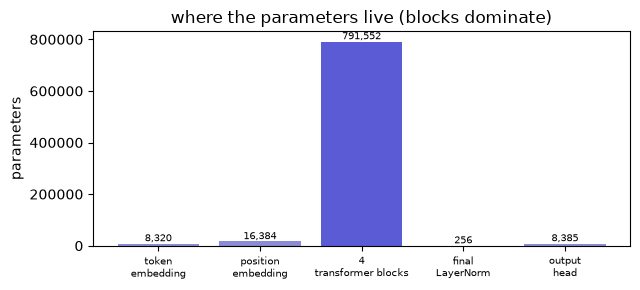

In [11]:
from collections import OrderedDict
groups = OrderedDict()
for name, p in model.named_parameters():
    top = name.split(".")[0]
    label = {"token_embedding": "token embedding", "position_embedding": "position embedding",
             "blocks": "4 transformer blocks", "ln_f": "final LayerNorm",
             "lm_head": "output head"}.get(top, top)
    groups[label] = groups.get(label, 0) + p.numel()

total = sum(groups.values())
for label, n in groups.items():
    print(f"  {label:22s} {n:8,d}  ({100*n/total:4.1f}%)")
print(f"  {'TOTAL':22s} {total:8,d}")

import matplotlib.pyplot as plt
plt.figure(figsize=(6.5, 3))
bars = plt.bar([l.replace(" ", "\n", 1) for l in groups], list(groups.values()),
               color=["#5b5bd6" if "blocks" in l else "#8b8bd6" for l in groups])
for b, n in zip(bars, groups.values()):
    plt.text(b.get_x() + b.get_width() / 2, n, f"{n:,}", ha="center", va="bottom", fontsize=7)
plt.ylabel("parameters"); plt.title("where the parameters live (blocks dominate)")
plt.xticks(fontsize=7); plt.tight_layout(); plt.show()

<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li>The loop reads each parameter tensor's name (like <code>blocks.0.sa...</code>) and adds its size to the matching component.</li>
<li>The token and position embeddings and the output head are small -- a few thousand numbers each; the four blocks together hold 791,552, about 96%.</li>
<li>Inside each block most of that is the feed-forward network's two big matrices (the 4&times; expand and contract from notebook 06).</li>
<li>The bar chart makes the imbalance plain: real capacity lives in the stacked blocks, which is why "make it bigger" almost always means more or wider blocks.</li>
</ul>
</details>

## Forward pass and an untrained sample

A forward pass returns logits with shape `(batch, time, vocab)` and, when given targets, a loss near `ln(vocab) = 4.17`. This is because a freshly built model has random weights and is essentially guessing all 65 characters as equally likely (notebook 01's random baseline). Generating from it produces pure gibberish. That is our starting line; notebook 09 trains it into something that writes Shakespeare.

In [12]:
import math
B, T = 4, cfg.block_size
x = torch.randint(0, vocab_size, (B, T), device=device)
y = torch.randint(0, vocab_size, (B, T), device=device)
logits, loss = model(x, y)
print("logits:", tuple(logits.shape), "| loss: %.3f | ln(vocab) = %.3f" % (loss.item(), math.log(vocab_size)))

stoi = {c:i for i,c in enumerate(sorted(set(text)))}; itos = {i:c for c,i in stoi.items()}
decode = lambda l: "".join(itos[i] for i in l)
ctx = torch.zeros((1,1), dtype=torch.long, device=device)
print("\n--- untrained sample (gibberish) ---")
print(decode(model.generate(ctx, 200)[0].tolist()))

logits: (4, 128, 65) | loss: 4.190 | ln(vocab) = 4.174

--- untrained sample (gibberish) ---



VTT&&l YdspiAoJ:U!EeOa
,fpVmCyYbYKKkcE,HHO,ZGNBVV3nqjOyxn&Jm'Y$tvP. p,3piNbyS?U.v-?AaslxZYnVHmcuyYVw;ZGmYyrbEtDOeKZOJ'dFTjCfCi.?yi-GUx
Hz
CxF.DbhmKa.!qXIfzFWk3f,qcZdsS&
.KMvnOMvA!vs.'uStVFn3sg?gegse
D


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>x = torch.randint(0, vocab_size, (B, T), device=device)</code>: random token ids shaped like a real batch, just to exercise the forward pass.</li>
<li><code>logits, loss = model(x, y)</code>: run the model; with targets it also returns the loss.</li>
<li><code>math.log(vocab_size)</code>: ln(65) = 4.174, the know-nothing baseline; the untrained loss lands right next to it.</li>
<li><code>ctx = torch.zeros((1,1), dtype=torch.long, device=device)</code>: the generation prompt: one sequence holding one token (id 0, the newline) -- a neutral start.</li>
<li><code>decode(model.generate(ctx, 200)[0].tolist())</code>: generate 200 tokens, take the first (only) sequence, turn the tensor into a plain list, decode to text. Untrained = gibberish.</li>
</ul>
</details>

**If your loss is not exactly the book's 4.197.** We seeded the generator with `torch.manual_seed(1337)`, so the same machine gives the same answer every time. But the seed feeds a *separate* stream of random numbers on each kind of hardware: the book's 4.197 came from a Colab GPU, the same code on a plain CPU gives 4.199, and on an Apple GPU 4.190. Same seed, same code, different silicon.

So the printed digits are "what one machine got", not a target to match. The claim that holds everywhere is the one that matters: the number lands just above ln(65) = 4.174, because a model that has learned nothing cannot do better than "all 65 characters equally likely". For the same reason, the gibberish below will not be *your* gibberish, character for character.

### Follow the shapes through one forward pass

The diagram at the top of this page traced the path from token ids to logits. Here it is with real tensors, so you can watch each stage keep the batch and time axes and change only the last one: ids become 128-wide vectors, the blocks refine them without reshaping, and the head finally opens each position out to one score per vocabulary character.

In [13]:
# Run the model's stages by hand and print the shape after each (mirrors GPT.forward).
idx = torch.randint(0, cfg.vocab_size, (1, 20), device=device)
tok = model.token_embedding(idx)
pos = model.position_embedding(torch.arange(20, device=device))
h = tok + pos
hb = model.blocks(h)
hn = model.ln_f(hb)
logits = model.lm_head(hn)
print(f"idx (token ids)        : {tuple(idx.shape)}           (batch, time)")
print(f"token + position embed : {tuple(h.shape)}    (batch, time, width 128)")
print(f"after the 4 blocks     : {tuple(hb.shape)}    (same shape -- blocks preserve it)")
print(f"after final LayerNorm  : {tuple(hn.shape)}    (same shape)")
print(f"logits (lm_head)       : {tuple(logits.shape)}     (a score per vocab char, per position)")

idx (token ids)        : (1, 20)           (batch, time)
token + position embed : (1, 20, 128)    (batch, time, width 128)
after the 4 blocks     : (1, 20, 128)    (same shape -- blocks preserve it)
after final LayerNorm  : (1, 20, 128)    (same shape)
logits (lm_head)       : (1, 20, 65)     (a score per vocab char, per position)


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>idx</code>: a batch of token ids, shape (batch, time).</li>
<li><code>token_embedding + position_embedding</code>: each id becomes a 128-wide vector and the position vector is added -- now (batch, time, 128).</li>
<li><code>model.blocks(h)</code>: the four Transformer blocks run and keep the shape exactly, just refining the numbers.</li>
<li><code>ln_f</code> then <code>lm_head</code>: a final normalize, then a linear layer opens each position out to one score per vocabulary character -- (batch, time, 65).</li>
<li>Every stage keeps the batch and time axes; only the last axis changes. That regularity is exactly what lets the blocks stack.</li>
</ul>
</details>

## Recap

The GPT is assembled and lives in `gpt.py`: embeddings, then blocks, then a final norm, then logits, with about a million numbers in total, and both the forward pass and `generate` already working (just untrained so far). Every line traces back to something you built by hand in Part 1; nothing here is new, it has only been wired together.

Next, notebook 09 trains it on Shakespeare and we watch the loss fall and the text sharpen.